# Project 02 — Black-Scholes, Greeks & Derivatives Risk

## Notebook 03 — Greeks & Sensitivity Analysis

This notebook calculates the primary Black-Scholes option Greeks and examines
how option values respond to changes in market and contract inputs.

### Objectives

- Calculate Delta, Gamma, Vega, Theta, and Rho.
- Apply the Greeks to the cleaned option-chain dataset.
- Examine how Greeks vary across strike prices.
- Use Greeks to interpret option risk and sensitivity.
- Perform simple sensitivity analysis on the underlying, volatility, and time.

The analysis builds on the Black-Scholes pricing framework developed in Notebook 02.

## 1. Load Market Data

Notebook 01 created the cleaned SPY option-chain dataset, which is reused
throughout Project 02.

Notebook 03 uses the same market data and model inputs as Notebook 02 so that
the Greeks are calculated consistently with the Black-Scholes prices.

In [25]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_02_derivatives_risk_engine.src.black_scholes import black_scholes_price
from project_02_derivatives_risk_engine.src.greeks import calculate_greeks

In [26]:
data_path =Path("../results/csv/spy_option_chain_clean.csv")
options = pd.read_csv(data_path)
print(f"Loaded {len(options)} option contracts")

options.head()

Loaded 256 option contracts


,contract_symbol,option_type,expiration,spot,strike,days_to_expiry,T,moneyness,bid,ask,mid_price,last_price,volume,open_interest,implied_volatility,intrinsic_value,time_value,in_the_money
0,SPY261120C00620000,call,2026-11-20,774.886292,620.0,44,0.120548,0.800117,156.37,160.18,158.275,158.81,6.0,45,0.485814,154.886292,3.388708,True
1,SPY261120C00625000,call,2026-11-20,774.886292,625.0,44,0.120548,0.806570,151.51,155.25,153.380,154.00,2.0,7,0.474035,149.886292,3.493708,True
2,SPY261120C00630000,call,2026-11-20,774.886292,630.0,44,0.120548,0.813023,147.20,150.37,148.785,145.85,2.0,785,0.463384,144.886292,3.898708,True
3,SPY261120C00635000,call,2026-11-20,774.886292,635.0,44,0.120548,0.819475,142.34,144.60,143.470,134.00,2.0,141,0.431982,139.886292,3.583708,True
4,SPY261120C00640000,call,2026-11-20,774.886292,640.0,44,0.120548,0.825928,137.35,139.56,138.455,138.85,1.0,414,0.418005,134.886292,3.568708,True


## 2. Model Assumptions

The Greeks are calculated using the same Black-Scholes assumptions as
Notebook 02.

In [27]:
risk_free_rate = 0.04  # 2% annual risk-free rate
dividend_yield = 0.012  # 1.2% annual dividend yield
volatility = 0.2  # 20% annual volatility

## 3. Option Greeks

The Black-Scholes Greeks measure how sensitive an option's theoretical value
is to changes in its key inputs.

| Greek | Measures sensitivity to |
|---|---|
| Delta | Underlying price |
| Gamma | Delta / underlying price |
| Vega | Volatility |
| Theta | Time |
| Rho | Interest rate |

Together, the Greeks provide a practical framework for understanding and
managing option risk.

### 3.1 Delta

Delta measures the sensitivity of an option's price to a change in the
underlying asset price.

For a call:

$$
\Delta_{call} = e^{-qT}N(d_1)
$$

For a put:

$$
\Delta_{put} = e^{-qT}[N(d_1)-1]
$$

Delta can also be interpreted approximately as the expected change in option
value for a small change in the underlying price.

For example, a call with a Delta of 0.60 would theoretically gain
approximately $0.60 for a $1 increase in the underlying, all else equal.

### 3.2 Gamma

Gamma measures the sensitivity of Delta to a change in the underlying price.

For both calls and puts:

$$
\Gamma =
\frac{e^{-qT}N'(d_1)}
{S\sigma\sqrt{T}}
$$

Gamma is particularly important for risk management because it captures the
non-linearity of an option position.

### 3.3 Vega

Vega measures the sensitivity of an option's price to a change in volatility.

For both calls and puts:

$$
Vega =
S e^{-qT}N'(d_1)\sqrt{T}
$$

The convention used here expresses Vega as the change in option value for a
1.00 change in volatility. Therefore, a 1 percentage-point volatility change
corresponds to:

$$
\Delta V \approx Vega \times 0.01
$$

### 3.4 Theta

Theta measures the sensitivity of an option's price to the passage of time.

For a call:

$$
\Theta_{call} =
-\frac{S e^{-qT}N'(d_1)\sigma}{2\sqrt{T}}
-rKe^{-rT}N(d_2)
+qSe^{-qT}N(d_1)
$$

For a put:

$$
\Theta_{put} =
-\frac{S e^{-qT}N'(d_1)\sigma}{2\sqrt{T}}
+rKe^{-rT}N(-d_2)
-qSe^{-qT}N(-d_1)
$$

The formulas above express Theta on a per-year basis.

### 3.5 Rho

Rho measures the sensitivity of an option's price to a change in the
risk-free interest rate.

For a call:

$$
Rho_{call} =
KT e^{-rT}N(d_2)
$$

For a put:

$$
Rho_{put} =
-KT e^{-rT}N(-d_2)
$$

Rho is generally less significant for very short-dated options but becomes
more relevant as time to maturity increases.

## 4. Apply Greeks to the Option Chain

The reusable Greek calculation function can now be applied to every option
contract in the dataset.

The resulting columns provide a risk profile for each option under the
Black-Scholes assumptions defined above.

In [28]:
greeks = options.apply(
        lambda row: calculate_greeks(
            S=row['spot'],
            K=row['strike'],
            T=row['T'],
            r=risk_free_rate,
            q=dividend_yield,
            sigma=volatility,
            option_type=row['option_type']
        ),
        axis=1,
        result_type='expand'
)

options[['delta', 'gamma', 'vega', 'theta', 'rho']] = greeks

In [29]:
options[
    [
        "option_type",
        "strike",
        "T",
        "delta",
        "gamma",
        "vega",
        "theta",
        "rho"
    ]
].head(10)

,option_type,strike,T,delta,gamma,vega,theta,rho
0,call,620.0,0.120548,0.998063,0.000033,0.470951,-15.775228,74.333396
1,call,625.0,0.120548,0.997817,0.000047,0.684824,-16.146195,74.909805
2,call,630.0,0.120548,0.997465,0.000068,0.979818,-16.582087,75.476114
3,call,635.0,0.120548,0.996970,0.000095,1.379848,-17.101899,76.028724
4,call,640.0,0.120548,0.996284,0.000132,1.913324,-17.728123,76.563066
5,call,645.0,0.120548,0.995348,0.000181,2.613154,-18.486722,77.073442
6,call,650.0,0.120548,0.994089,0.000243,3.516452,-19.406842,77.552886
7,call,655.0,0.120548,0.992421,0.000322,4.663876,-20.520246,77.993040
8,call,660.0,0.120548,0.990241,0.000421,6.098574,-21.860411,78.384069
9,call,665.0,0.120548,0.987433,0.000543,7.864673,-23.461268,78.714632


## 4. Greeks Across Strike

The Greeks provide different perspectives on option risk.

Plotting each Greek across strike prices helps visualize how the risk profile
changes with option moneyness for the selected expiration.

In [30]:
calls = options[options['option_type'] == 'call']
puts = options[options['option_type'] == 'put']

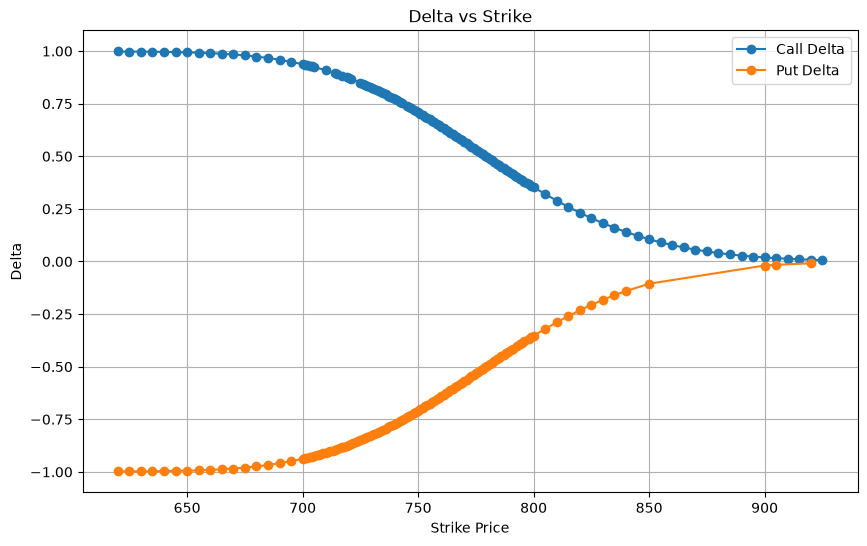

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(calls['strike'], calls['delta'], label='Call Delta', marker='o')
plt.plot(puts['strike'], puts['delta'], label='Put Delta', marker='o')
plt.xlabel('Strike Price')
plt.ylabel('Delta')
plt.title("Delta vs Strike")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/delta_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

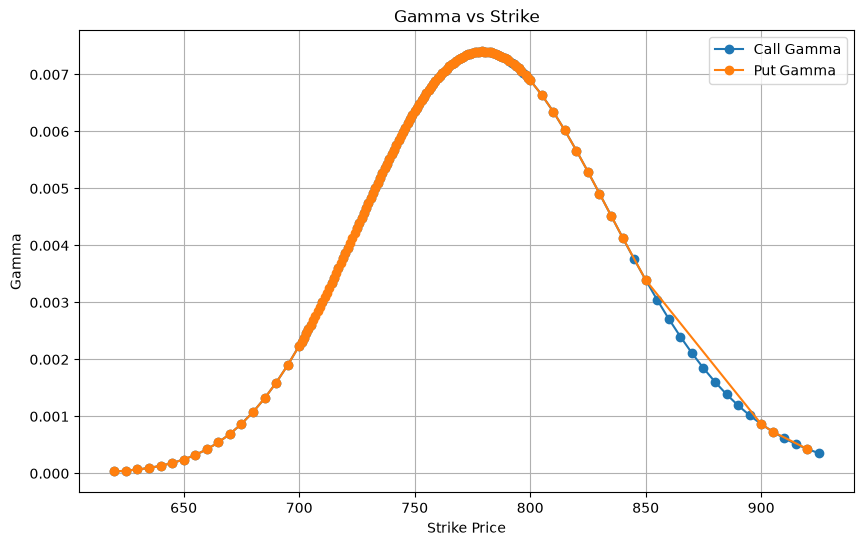

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(calls['strike'], calls['gamma'], label='Call Gamma', marker='o')
plt.plot(puts['strike'], puts['gamma'], label='Put Gamma', marker='o')
plt.xlabel('Strike Price')
plt.ylabel('Gamma')
plt.title("Gamma vs Strike")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/gamma_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

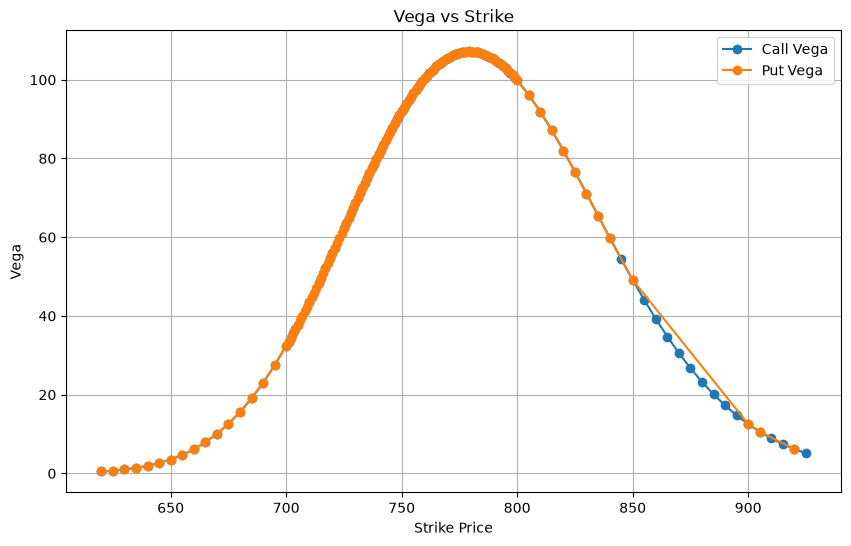

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(calls['strike'], calls['vega'], label='Call Vega', marker='o')
plt.plot(puts['strike'], puts['vega'], label='Put Vega', marker='o')
plt.xlabel('Strike Price')
plt.ylabel('Vega')
plt.title("Vega vs Strike")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/vega_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

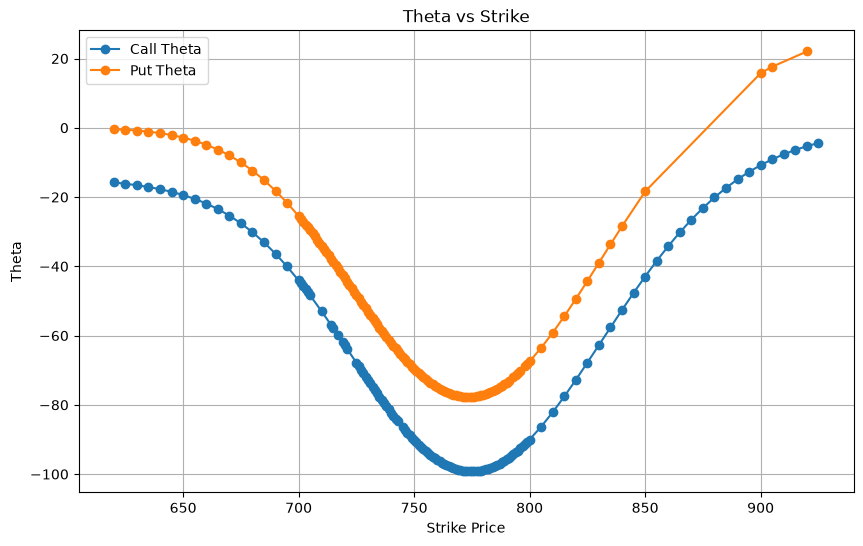

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(calls['strike'], calls['theta'], label='Call Theta', marker='o')
plt.plot(puts['strike'], puts['theta'], label='Put Theta', marker='o')
plt.xlabel('Strike Price')
plt.ylabel('Theta')
plt.title("Theta vs Strike")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/theta_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

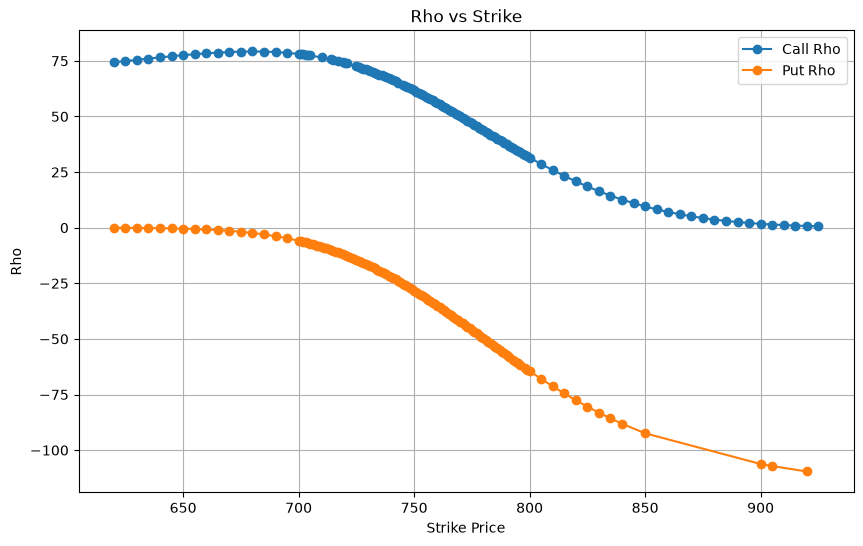

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(calls['strike'], calls['rho'], label='Call Rho', marker='o')
plt.plot(puts['strike'], puts['rho'], label='Put Rho', marker='o')
plt.xlabel('Strike Price')
plt.ylabel('Rho')
plt.title("Rho vs Strike")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/rho_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Sensitivity Analysis

Greeks provide local measures of risk. Sensitivity analysis complements them by
showing how the option price changes when key model inputs are varied.

We will examine the effect of:

- Underlying price
- Volatility
- Time to maturity

The analysis uses a representative at-the-money option.

### 5.1 Select a Representative Option

We select a call option closest to the current spot price so that the
sensitivity analysis focuses on an approximately at-the-money contract.

In [36]:
atm_call = calls.iloc[
    (calls["strike"] - calls["spot"]).abs().argsort().iloc[0]
]

atm_call

contract_symbol       SPY261120C00775000
option_type                         call
expiration                    2026-11-20
spot                          774.886292
strike                             775.0
days_to_expiry                        44
T                               0.120548
moneyness                       1.000147
bid                                16.54
ask                                16.62
mid_price                          16.58
last_price                         16.77
volume                             532.0
open_interest                      10543
implied_volatility              0.153603
intrinsic_value                      0.0
time_value                         16.58
in_the_money                       False
delta                           0.531595
gamma                           0.007379
vega                          106.823655
theta                          -99.24233
rho                            46.924371
Name: 78, dtype: object

### 5.2 Underlying Price Sensitivity

The underlying price is varied around the current spot price while keeping
strike, volatility, interest rate, dividend yield, and time to maturity
constant.

This illustrates the non-linear relationship between the underlying price
and the option value.

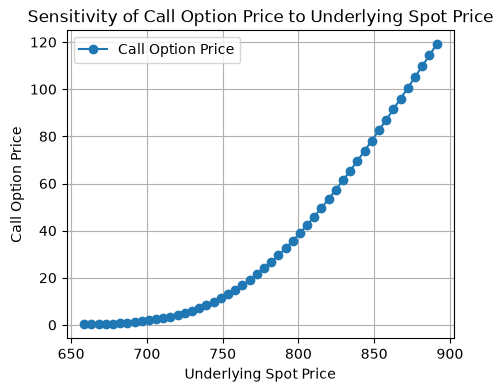

In [37]:
spot_range = np.linspace(atm_call["spot"] * 0.85, atm_call["spot"] * 1.15, 50)

underlying_prices = []

for spot in spot_range:
    price = black_scholes_price(
        S=spot,
        K=atm_call["strike"],
        T=atm_call["T"],
        r=risk_free_rate,
        q=dividend_yield,
        sigma=volatility,
        option_type="call"
    )

    underlying_prices.append(price)

plt.figure(figsize=(5, 4))
plt.plot(spot_range, underlying_prices, label="Call Option Price", marker="o")
plt.xlabel("Underlying Spot Price")
plt.ylabel("Call Option Price")
plt.title("Sensitivity of Call Option Price to Underlying Spot Price")
plt.legend()
plt.grid(True)
plt.savefig(
    "../results/figures/call_price_vs_underlying.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.3 Volatility Sensitivity

Volatility is one of the most important drivers of option value.

We vary volatility while keeping the underlying price, strike, interest rate,
dividend yield, and time to maturity constant.

This illustrates the positive relationship between volatility and the value of
both call and put options.

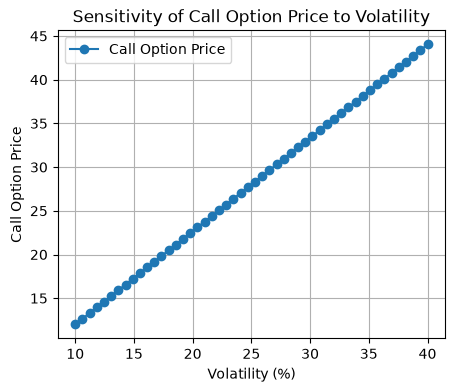

In [38]:
volatility_range = np.linspace(0.10, 0.40, 50)

volatility_prices = []

for sigma in volatility_range:
    price = black_scholes_price(
        S=atm_call["spot"],
        K=atm_call["strike"],
        T=atm_call["T"],
        r=risk_free_rate,
        q=dividend_yield,
        sigma=sigma,
        option_type="call"
    )

    volatility_prices.append(price)

plt.figure(figsize=(5, 4))
plt.plot(volatility_range * 100, volatility_prices, label="Call Option Price", marker="o")
plt.xlabel("Volatility (%)")
plt.ylabel("Call Option Price")
plt.title("Sensitivity of Call Option Price to Volatility")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/call_price_vs_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.4 Time-to-Maturity Sensitivity

Time to maturity affects the value of an option because a longer time horizon
generally provides more opportunity for the underlying asset to move.

We vary time to maturity while keeping the other model inputs constant.

This illustrates the relationship between option value and remaining time.

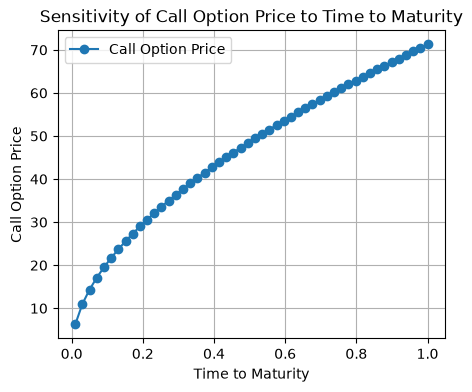

In [39]:
time_range = np.linspace(0.01, 1.0, 50)

time_prices = []

for time_to_maturity in time_range:
    price = black_scholes_price(
        S=atm_call["spot"],
        K=atm_call["strike"],
        T=time_to_maturity,
        r=risk_free_rate,
        q=dividend_yield,
        sigma=volatility,
        option_type="call"
    )

    time_prices.append(price)

plt.figure(figsize=(5, 4))
plt.plot(time_range, time_prices, label="Call Option Price", marker="o")
plt.xlabel("Time to Maturity")
plt.ylabel("Call Option Price")
plt.title("Sensitivity of Call Option Price to Time to Maturity")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/call_price_vs_time_to_maturity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6. Risk Interpretation

The Greeks provide a practical framework for understanding option risk:

- **Delta:** Measures directional exposure to the underlying asset.
- **Gamma:** Measures how quickly Delta changes as the underlying moves and
  therefore captures option non-linearity.
- **Vega:** Measures sensitivity to changes in implied volatility.
- **Theta:** Measures the effect of the passage of time on option value.
- **Rho:** Measures sensitivity to changes in the risk-free interest rate.

From a risk-management perspective, these sensitivities help identify which
market variables are most relevant to an option position and how the position
may respond to changing market conditions.

## 7. Key Takeaways

- The Black-Scholes Greeks provide a quantitative view of option sensitivities.
- Delta and Gamma describe the option's exposure to movements in the
  underlying asset.
- Vega captures sensitivity to volatility, while Theta captures time decay.
- Rho measures sensitivity to interest rates.
- The Greek profiles vary significantly with strike price and therefore
  provide useful information about option moneyness and risk.
- Sensitivity analysis complements the Greeks by showing how option value
  changes when key model inputs are varied.
- These measures form an important foundation for derivatives risk management
  and stress testing.